In [ ]:
Implementation and Performance Comparison of Logistic Regression Algorithm on Multiple Datasets

In [ ]:
1. Logistic Regression on Titanic Dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
train = pd.read_csv("Titanic-Dataset.csv")

# Fill Missing Values
train['Age'].fillna(train['Age'].mean(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Drop Unnecessary Columns
train.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Label Encoding
le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])

# Features and Target
X = train.drop('Survived', axis=1)
y = train['Survived']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, pred)

print("Titanic Dataset Accuracy:", accuracy)

print(classification_report(y_test, pred))

Titanic Dataset Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
2. Logistic Regression on Heart Disease Dataset

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
train = pd.read_csv("heart.csv")

# Features and Target
X = train.drop('target', axis=1)
y = train['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, pred)

print("Heart Disease Dataset Accuracy:", accuracy)

print(classification_report(y_test, pred))

Heart Disease Dataset Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [ ]:
3. Logistic Regression on Customer Churn Dataset

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
train = pd.read_csv("customer_churn_dataset-training-master.csv")
test = pd.read_csv("customer_churn_dataset-testing-master.csv")

# Handle Missing Values
num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

for col in num_cols:
    train[col].fillna(train[col].mean(), inplace=True)
    test[col].fillna(test[col].mean(), inplace=True)

cat_cols = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

# Label Encoding
le_gender = LabelEncoder()
le_subscription = LabelEncoder()
le_contract = LabelEncoder()

train['Gender'] = le_gender.fit_transform(train['Gender'])
test['Gender'] = le_gender.transform(test['Gender'])

train['Subscription Type'] = le_subscription.fit_transform(train['Subscription Type'])
test['Subscription Type'] = le_subscription.transform(test['Subscription Type'])

train['Contract Length'] = le_contract.fit_transform(train['Contract Length'])
test['Contract Length'] = le_contract.transform(test['Contract Length'])

# Drop CustomerID
train = train.drop('CustomerID', axis=1)
test = test.drop('CustomerID', axis=1)

# Fill Missing Target Values
train['Churn'] = train['Churn'].fillna(train['Churn'].mode()[0])
test['Churn'] = test['Churn'].fillna(test['Churn'].mode()[0])

# Features and Target
X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, pred)

print("Customer Churn Dataset Accuracy:", accuracy)

print(classification_report(y_test, pred))

Customer Churn Dataset Accuracy: 0.5866343554851338
              precision    recall  f1-score   support

           0       0.94      0.23      0.37     33881
           1       0.53      0.98      0.69     30493

    accuracy                           0.59     64374
   macro avg       0.74      0.61      0.53     64374
weighted avg       0.75      0.59      0.52     64374



In [ ]:
4. Accuracy Comparison of Multiple Datasets

          Dataset  Accuracy
0         Titanic      0.81
1   Heart Disease      0.85
2  Customer Churn      0.60


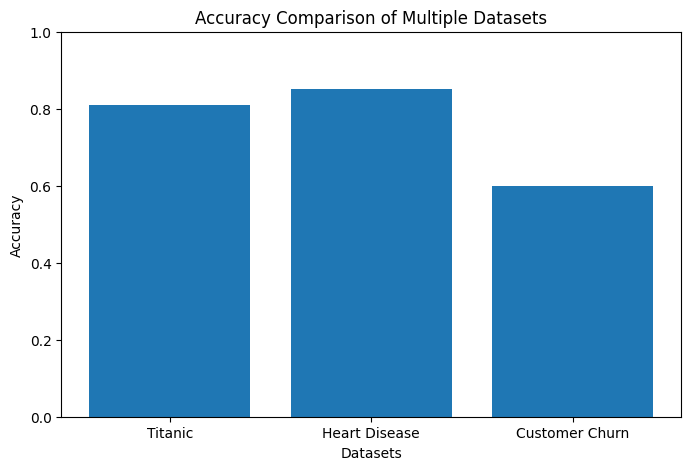

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Accuracy Results
results = {
    'Dataset': [
        'Titanic',
        'Heart Disease',
        'Customer Churn'
    ],
    
    'Accuracy': [
        0.81,
        0.85,
        0.60
    ]
}

# Create DataFrame
results_df = pd.DataFrame(results)

# Print Table
print(results_df)

# Accuracy Comparison Graph
plt.figure(figsize=(8,5))

plt.bar(results_df['Dataset'], results_df['Accuracy'])

plt.title("Accuracy Comparison of Multiple Datasets")

plt.xlabel("Datasets")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()